In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("C:/Users/sanke/Downloads/titanic_toy.csv")

In [5]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [13]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=44)

In [17]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [19]:
x_train.isnull().mean()*100

Age       20.926966
Fare       5.056180
Family     0.000000
dtype: float64

In [23]:
mean_age=x_train['Age'].mean()
mean_fare=x_train['Fare'].mean()

median_age=x_train['Age'].median()
median_fare=x_train['Fare'].median()

In [29]:
x_train['Age_mean']=x_train['Age'].fillna(mean_age)
x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Fare_median']=x_train['Fare'].fillna(median_fare)

In [31]:
x_train.sample(5)

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
126,NaN,7.7500,0,29.690959,7.7500,28.0,7.7500
836,21.0,8.6625,0,21.000000,8.6625,21.0,8.6625
814,30.5,8.0500,0,30.500000,8.0500,30.5,8.0500
786,18.0,7.4958,0,18.000000,7.4958,18.0,7.4958
109,NaN,24.1500,1,29.690959,24.1500,28.0,24.1500


In [37]:

print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age Variance after mean imputation: ', x_train['Age_mean'].var())

print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance:  204.19746740580135
Age Variance after median imputation:  161.87884821643064
Age Variance after mean imputation:  161.40503049516215
Original Fare variable variance:  2370.5914432611103
Fare Variance after median imputation:  2266.317250385938
Fare Variance after mean imputation:  2250.5614967668766


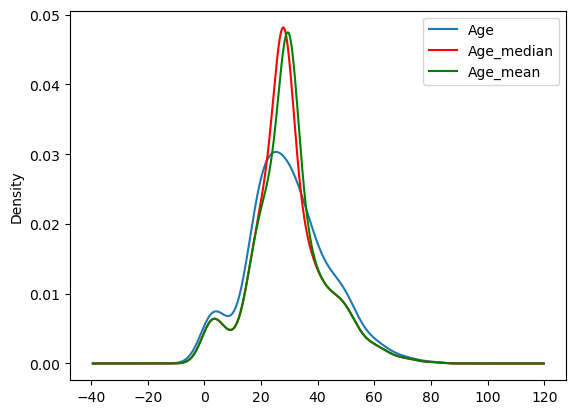

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

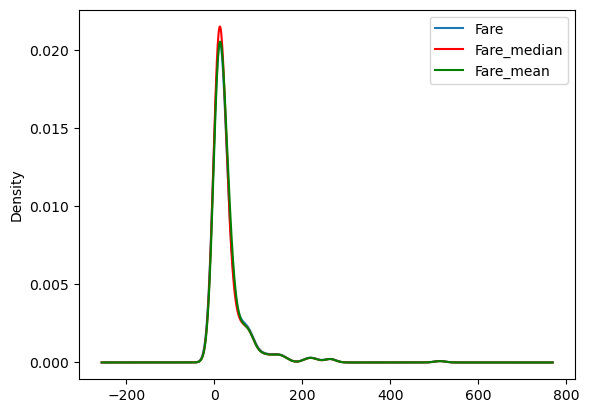

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [45]:
x_train.cov()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,204.197467,77.353811,-5.533816,204.197467,72.828465,204.197467,70.758760
Fare,77.353811,2370.591443,16.987366,60.636441,2370.591443,63.649871,2370.591443
Family,-5.533816,16.987366,2.420266,-4.374128,16.127246,-4.340271,16.298903
Age_mean,204.197467,60.636441,-4.374128,161.405030,57.566241,161.405030,55.930272
Fare_mean,72.828465,2370.591443,16.127246,57.566241,2250.561497,60.427092,2250.561497
Age_median,204.197467,63.649871,-4.340271,161.405030,60.427092,161.878848,58.682032
Fare_median,70.758760,2370.591443,16.298903,55.930272,2250.561497,58.682032,2266.317250


In [47]:
x_train.corr()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,1.000000,0.103856,-0.277843,1.000000,0.101260,1.000000,0.097971
Fare,0.103856,1.000000,0.220533,0.097609,1.000000,0.102331,1.000000
Family,-0.277843,0.220533,1.000000,-0.221310,0.218516,-0.219276,0.220073
Age_mean,1.000000,0.097609,-0.221310,1.000000,0.095513,0.998535,0.092476
Fare_mean,0.101260,1.000000,0.218516,0.095513,1.000000,0.100113,0.996518
Age_median,1.000000,0.102331,-0.219276,0.998535,0.100113,1.000000,0.096883
Fare_median,0.097971,1.000000,0.220073,0.092476,0.996518,0.096883,1.000000


<Axes: >

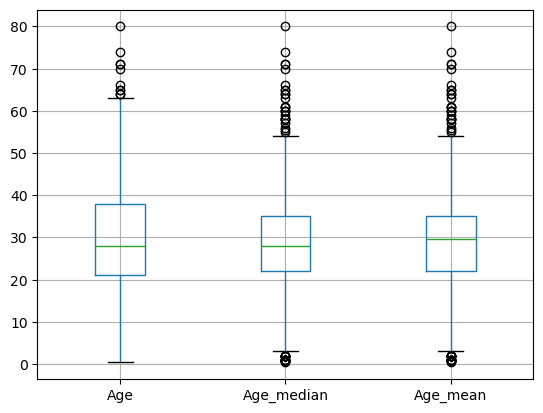

In [49]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

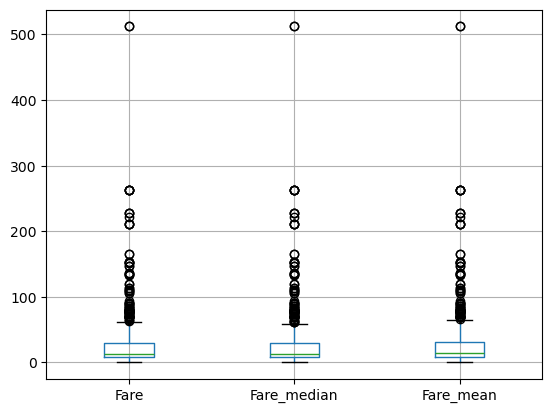

In [53]:

x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

# Using Sklearn

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=44)

In [64]:
impute1= SimpleImputer(strategy='median')
impute2= SimpleImputer(strategy='mean')

In [66]:
trf = ColumnTransformer([
    ('impute1',impute1,['Age']),
    ('impute2',impute2,['Fare'])
],remainder='passthrough')

In [68]:
trf.fit(x_train)

C:\Users\sanke\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('impute1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('impute2', SimpleImputer(), ['Fare'])])

In [72]:
trf.named_transformers_['impute1'].statistics_

array([28.])

In [74]:
trf.named_transformers_['impute2'].statistics_

array([31.10380192])

In [76]:
X_train = trf.transform(x_train)
X_test = trf.transform(x_test)

In [78]:
X_train

array([[45.    , 83.475 ,  1.    ],
       [35.    ,  7.8958,  0.    ],
       [28.    ,  8.05  ,  0.    ],
       ...,
       [23.    ,  7.8958,  0.    ],
       [10.    , 24.15  ,  2.    ],
       [ 1.    , 20.575 ,  3.    ]])

In [80]:
X_test

array([[ 29.        ,  21.        ,   1.        ],
       [ 19.        ,   6.75      ,   0.        ],
       [ 19.        ,  53.1       ,   1.        ],
       [ 49.        ,  25.9292    ,   0.        ],
       [ 16.        ,  39.4       ,   1.        ],
       [ 18.        ,   7.8542    ,   2.        ],
       [  0.83      ,  31.10380192,   2.        ],
       [ 16.        ,  46.9       ,   7.        ],
       [ 18.        ,   8.05      ,   0.        ],
       [ 31.        ,  52.        ,   1.        ],
       [ 35.        ,  26.        ,   0.        ],
       [ 23.        ,  13.        ,   0.        ],
       [ 28.        ,   7.225     ,   0.        ],
       [ 56.        ,  35.5       ,   0.        ],
       [ 11.        ,  18.7875    ,   0.        ],
       [ 28.        ,  27.7208    ,   0.        ],
       [ 56.        ,  26.55      ,   0.        ],
       [ 25.        ,   7.775     ,   0.        ],
       [ 32.5       ,  13.        ,   0.        ],
       [ 28.        ,   7.75   